In [1]:
using ITensors
using ITensorMPS
using JLD2
using Plots
using LaTeXStrings
using Printf
using Polynomials
using Statistics
using GLM
using DataFrames





In [2]:


data_dir = joinpath(@__DIR__, "data")

# all_data[truncation][sigma] = loaded_data_dict 
all_data = Dict{Float64, Dict{Float64, Any}}() 

sigma_values = [0.0, 5e-7, 6e-7, 7e-7, 8e-7, 9e-7, 1e-6, 1.2e-6, 1.4e-6, 1.6e-6, 1.8e-6, 2e-6, 2.2e-6, 2.4e-6, 2.6e-6, 2.8e-6, 3e-6, 4e-6, 5e-6, 1e-5, 1e-4, 1e-3, 1e-2, 2e-2, 1e-1, 2e-1, 5e-1, 7e-1, 1.0, 1.5, 2.0, 3.0, 5.0]
sigma_values_with_spike = [5e-7, 6e-7, 7e-7, 8e-7, 9e-7, 1e-6, 1.2e-6, 1.4e-6, 1.6e-6, 1.8e-6, 2e-6, 2.2e-6, 2.4e-6, 2.6e-6, 2.8e-6, 3e-6]

trunc_values = [1e-16, 8e-15, 6e-15, 4e-15, 2e-15, 1e-15, 8e-14, 6e-14, 1e-14, 1e-13, 1e-12, 1e-11, 1e-10, 1e-9, 1e-8] 

for trunc in trunc_values
    all_data[trunc] = Dict{Float64, Any}()
    
    for σ in sigma_values
        trunc_str = @sprintf("%.1e", trunc)
        
        # Explicitly format the clean case string
        if σ == 0.0
            sigma_str = "0.0e+00"
        else
            sigma_str = @sprintf("%.1e", σ)
        end

        file_name = "data_fid_$(trunc_str)_$(sigma_str).jld2" 
        file_path = joinpath(data_dir, file_name) 
        
        if isfile(file_path) 
            try
                data = load(file_path)
                all_data[trunc][σ] = data 
                println("Successfully loaded: Trunc=$trunc_str, σ=$sigma_str")
            catch e
                println("ERROR loading file: $file_name -> $e")
            end
        else
            println("File not found: $file_name") 
        end
    end
end


Successfully loaded: Trunc=1.0e-16, σ=0.0e+00
Successfully loaded: Trunc=1.0e-16, σ=5.0e-07
Successfully loaded: Trunc=1.0e-16, σ=6.0e-07
Successfully loaded: Trunc=1.0e-16, σ=7.0e-07
Successfully loaded: Trunc=1.0e-16, σ=8.0e-07
Successfully loaded: Trunc=1.0e-16, σ=9.0e-07
Successfully loaded: Trunc=1.0e-16, σ=1.0e-06
Successfully loaded: Trunc=1.0e-16, σ=1.2e-06
Successfully loaded: Trunc=1.0e-16, σ=1.4e-06
Successfully loaded: Trunc=1.0e-16, σ=1.6e-06
Successfully loaded: Trunc=1.0e-16, σ=1.8e-06
Successfully loaded: Trunc=1.0e-16, σ=2.0e-06
Successfully loaded: Trunc=1.0e-16, σ=2.2e-06
Successfully loaded: Trunc=1.0e-16, σ=2.4e-06
Successfully loaded: Trunc=1.0e-16, σ=2.6e-06
Successfully loaded: Trunc=1.0e-16, σ=2.8e-06
Successfully loaded: Trunc=1.0e-16, σ=3.0e-06
Successfully loaded: Trunc=1.0e-16, σ=4.0e-06
Successfully loaded: Trunc=1.0e-16, σ=5.0e-06
Successfully loaded: Trunc=1.0e-16, σ=1.0e-05
Successfully loaded: Trunc=1.0e-16, σ=1.0e-04
Successfully loaded: Trunc=1.0e-16

In [3]:
println(all_data[1e-16][1e-6]["avg_arr"])

[2.0, 3.9, 7.6, 13.1, 19.6, 25.2, 32.7, 38.8, 44.8, 49.9, 52.1, 56.9, 53.8, 53.6, 54.4, 51.6, 45.8, 37.2, 32.9, 24.2, 23.7, 24.8, 25.7, 26.4, 26.6, 27.6, 29.1, 29.4, 30.5, 31.4, 31.0, 32.2, 33.1, 32.5, 33.7, 33.6, 34.2, 34.2, 35.6, 35.4, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


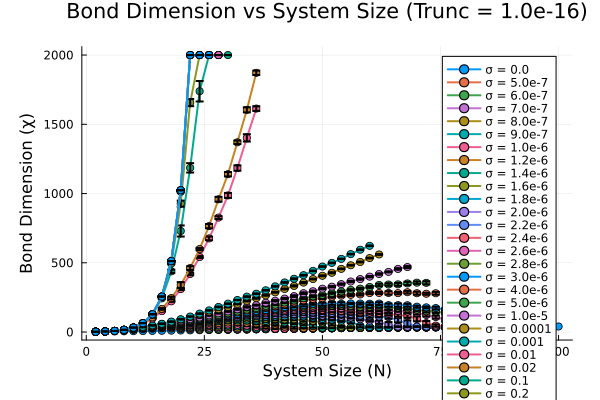

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_Fidelity\\images\\bd.png"

In [4]:
target_sigmas = sigma_values
target_trunc = 1e-16

p_bd = plot(
    title = "Bond Dimension vs System Size (Trunc = $target_trunc)",
    xlabel = "System Size (N)",
    ylabel = "Bond Dimension (χ)",
    legend = :topright,    
    margin = 5Plots.mm,
    grid = true
)

for σ in target_sigmas
    if haskey(all_data, target_trunc) && haskey(all_data[target_trunc], σ)
        data = all_data[target_trunc][σ]
        
        N_full = data["N_range"]
        bond_dims_full = data["avg_arr"]
        err_arr_full = data["err_arr"]
        
        mask = bond_dims_full .> 0
        N_vals = N_full[mask]
        bond_dims = bond_dims_full[mask]
        
        if σ == 0.0
            err_bars = nothing
        else
            err_bars = err_arr_full[mask]
        end

        plot!(p_bd, N_vals, bond_dims, 
            yerror = err_bars,
            label = "σ = $(σ)", 
            marker = :circle, 
            linewidth = 2)
    else
        println("Warning: Data not found for Trunc = $target_trunc, σ = $σ")
    end
end

display(p_bd)
savefig(p_bd, joinpath("images", "bd.png"))

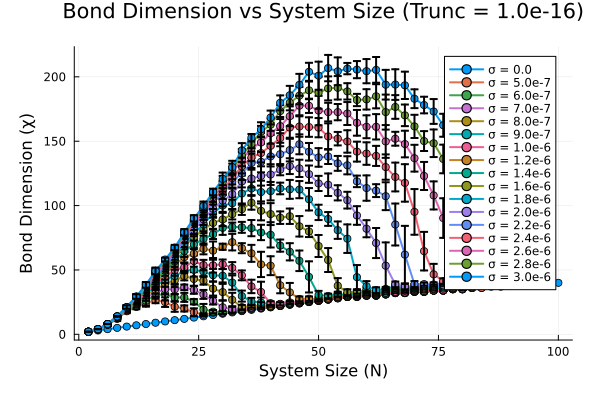

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_Fidelity\\images\\bd.png"

In [5]:
target_sigmas = union([0.0], sigma_values_with_spike)
target_trunc = 1e-16

p_bd = plot(
    title = "Bond Dimension vs System Size (Trunc = $target_trunc)",
    xlabel = "System Size (N)",
    ylabel = "Bond Dimension (χ)",
    legend = :topright,    
    margin = 5Plots.mm,
    grid = true
)

for σ in target_sigmas
    if haskey(all_data, target_trunc) && haskey(all_data[target_trunc], σ)
        data = all_data[target_trunc][σ]
        
        N_full = data["N_range"]
        bond_dims_full = data["avg_arr"]
        err_arr_full = data["err_arr"]
        
        mask = bond_dims_full .> 0
        N_vals = N_full[mask]
        bond_dims = bond_dims_full[mask]
        
        if σ == 0.0
            err_bars = nothing
        else
            err_bars = err_arr_full[mask]
        end

        plot!(p_bd, N_vals, bond_dims, 
            yerror = err_bars,
            label = "σ = $(σ)", 
            marker = :circle, 
            linewidth = 2)
    else
        println("Warning: Data not found for Trunc = $target_trunc, σ = $σ")
    end
end

display(p_bd)
savefig(p_bd, joinpath("images", "bd.png"))

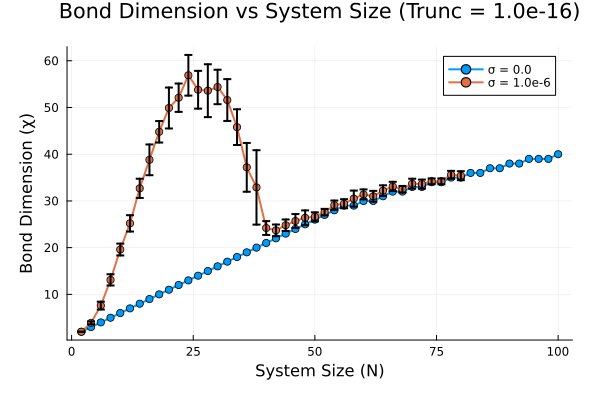

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_Fidelity\\images\\bd_some.png"

In [6]:
target_sigmas = [0.0, 1e-6] 
target_trunc = 1e-16

p_bd = plot(
    title = "Bond Dimension vs System Size (Trunc = $target_trunc)",
    xlabel = "System Size (N)",
    ylabel = "Bond Dimension (χ)",
    legend = :topright,    
    margin = 5Plots.mm,
    grid = true
)

for σ in target_sigmas
    if haskey(all_data, target_trunc) && haskey(all_data[target_trunc], σ)
        data = all_data[target_trunc][σ]
        
        N_full = data["N_range"]
        bond_dims_full = data["avg_arr"]
        err_arr_full = data["err_arr"]
        
        mask = bond_dims_full .> 0
        N_vals = N_full[mask]
        bond_dims = bond_dims_full[mask]
        
        if σ == 0.0
            err_bars = nothing
        else
            err_bars = err_arr_full[mask]
        end

        plot!(p_bd, N_vals, bond_dims, 
            yerror = err_bars,
            label = "σ = $(σ)", 
            marker = :circle, 
            linewidth = 2)
    else
        println("Warning: Data not found for Trunc = $target_trunc, σ = $σ")
    end
end

display(p_bd)
savefig(p_bd, joinpath("images", "bd_some.png"))

# Spectra

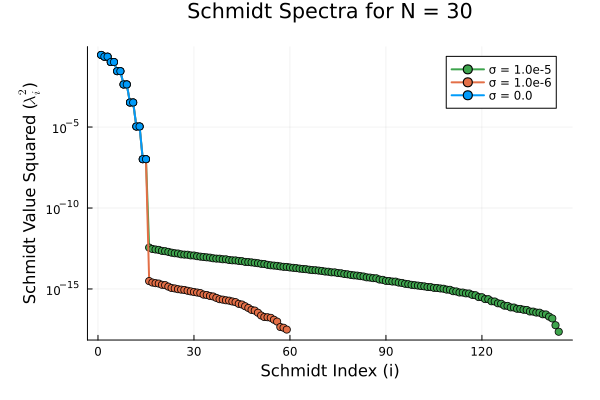

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_Fidelity\\images\\spectra_N=30.png"

In [38]:
target_sigmas = [0.0, 1e-6, 1e-5] 
target_trunc = 1e-16
target_N = 30

p_spectra = plot(
    title = "Schmidt Spectra for N = $target_N",
    xlabel = "Schmidt Index (i)",
    ylabel = L"Schmidt Value Squared ($\lambda_{i}^{2}$)",
    legend = :topright,
    yscale = :log10,
    margin = 5Plots.mm,
    grid = true
)

for σ in sort(target_sigmas, rev=true) 
    if haskey(all_data, target_trunc) && haskey(all_data[target_trunc], σ)
        data = all_data[target_trunc][σ]
        
        N_full = data["N_range"]
        
        idx = findfirst(==(target_N), N_full)
        
        if !isnothing(idx)
            spectra = data["spectra_avg"][idx, :]
            
            valid_spectra = filter(x -> x > 0, spectra)
            
            sorted_spectra = sort(valid_spectra, rev=true)

            if σ == 1e-6
                palette_idx = 2  
            elseif σ == 1e-5
                palette_idx = 3 
            else
                palette_idx = 1  
            end
            
            plot!(p_spectra, 1:length(sorted_spectra), sorted_spectra, 
                label = "σ = $(σ)", 
                marker = :circle, 
                color = palette_idx,
                linewidth = 2)
        else
            println("Warning: N = $target_N not found for Trunc = $target_trunc, σ = $σ")
        end
    else
        println("Warning: Data not found for Trunc = $target_trunc, σ = $σ")
    end
end

display(p_spectra)
savefig(p_spectra, joinpath("images", "spectra_N=$target_N.png"))

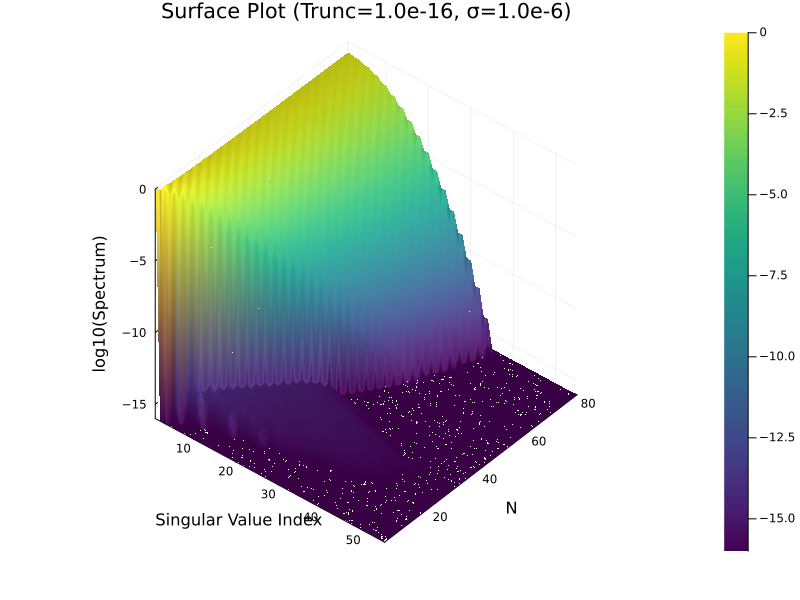

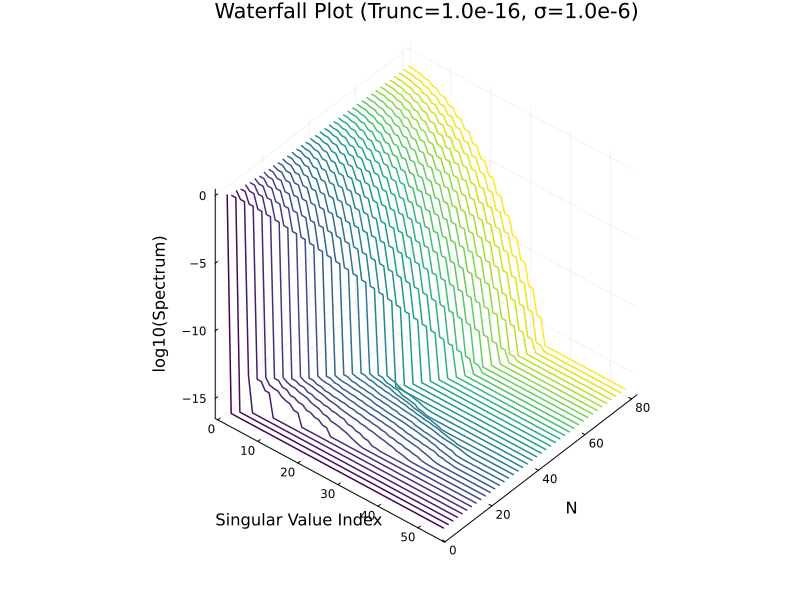

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_Fidelity\\images\\waterfall_sigma=1.0e-6.png"

In [39]:

target_trunc = 1e-16
target_sigma = 1e-6 

if haskey(all_data, target_trunc) && haskey(all_data[target_trunc], target_sigma)
    data = all_data[target_trunc][target_sigma]
    
    raw_N_vals = data["N_range"]
    raw_spectra = data["spectra_avg"]
    

    valid_N_indices = Int[]
    for n_idx in 1:length(raw_N_vals)
        spec = typeof(raw_spectra) <: AbstractMatrix ? raw_spectra[n_idx, :] : raw_spectra[n_idx]
        if any(x -> x > 1e-16, spec)
            push!(valid_N_indices, n_idx)
        end
    end
    
    N_vals = raw_N_vals[valid_N_indices]
    spectra = typeof(raw_spectra) <: AbstractMatrix ? raw_spectra[valid_N_indices, :] : raw_spectra[valid_N_indices]
    
    if isempty(N_vals)
        println("No valid data found to plot for Truncation $target_trunc and Sigma $target_sigma.")
    else
        true_max_len = 0
        for n_idx in 1:length(N_vals)
            spec = typeof(spectra) <: AbstractMatrix ? sort(spectra[n_idx, :], rev=true) : sort(spectra[n_idx], rev=true)
            
            valid_indices = findall(x -> x >= 1e-16, spec)
            if !isempty(valid_indices)
                true_max_len = max(true_max_len, valid_indices[end])
            end
        end
        
        true_max_len = max(1, true_max_len) + 10 
        
        X = 1:true_max_len
        Y = N_vals
        
        Z = fill(1e-16, (length(Y), true_max_len))
        line_colors = palette(:viridis, length(N_vals))

        
        for n_idx in 1:length(N_vals)
            spec = typeof(spectra) <: AbstractMatrix ? sort(spectra[n_idx, :], rev=true) : sort(spectra[n_idx], rev=true)
            for i in 1:min(true_max_len, length(spec))
                val = spec[i]
                Z[n_idx, i] = val < 1e-16 ? 1e-16 : val
            end
        end


        p_surface = surface(X, Y, log10.(Z), 
                            color = :viridis,
                            xlabel = "Singular Value Index", 
                            ylabel = "N", 
                            zlabel = "log10(Spectrum)",
                            title = "Surface Plot (Trunc=$(target_trunc), σ=$(target_sigma))",
                            camera = (40, 40),
                            size = (800, 600))
        display(p_surface)
        

        p_waterfall = plot(xlabel = "Singular Value Index", 
                           ylabel = "N", 
                           zlabel = "log10(Spectrum)",
                           title = "Waterfall Plot (Trunc=$(target_trunc), σ=$(target_sigma))",
                           camera = (40, 40), 
                           legend = false,
                           size = (800, 600))
                           
        for n_idx in 1:length(Y)
            plot!(p_waterfall, X, fill(Y[n_idx], length(X)), log10.(Z[n_idx, :]), linewidth = 1.5, color = line_colors[n_idx])
        end
        display(p_waterfall)
    end
else
    println("Data for Truncation $target_trunc and Sigma $target_sigma not found.")
end

savefig(p_surface, joinpath("images", "surface_sigma=$(target_sigma).png"))
savefig(p_waterfall, joinpath("images", "waterfall_sigma=$(target_sigma).png"))

# Entropies

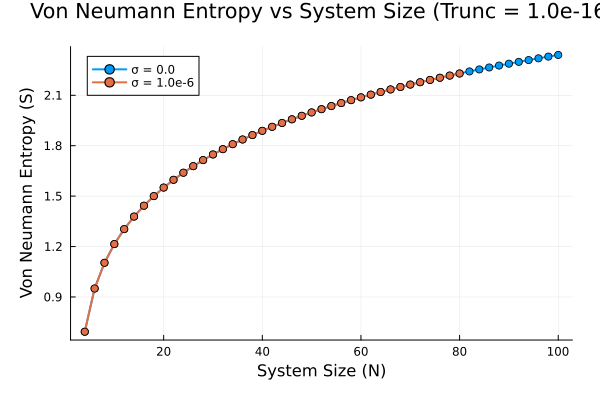

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_Fidelity\\images\\ent_vn.png"

In [40]:
target_sigmas = [0.0, 1e-6] 
target_trunc = 1e-16

p_vn = plot(
    title = "Von Neumann Entropy vs System Size (Trunc = $target_trunc)",
    xlabel = "System Size (N)",
    ylabel = "Von Neumann Entropy (S)",
    legend = :topleft,    
    # xscale = :log10,
    margin = 5Plots.mm,
    grid = true
)

for σ in target_sigmas
    if haskey(all_data, target_trunc) && haskey(all_data[target_trunc], σ)
        data = all_data[target_trunc][σ]
        
        N_range = data["N_range"]
        vn_entropy = data["vn_avg"]

        mask = vn_entropy .> 0.0
        
        valid_N = N_range[mask]
        valid_vn = vn_entropy[mask]
        
        if !isempty(valid_vn)
            plot!(p_vn, valid_N, valid_vn, 
                label = "σ = $(σ)", 
                marker = :circle, 
                linewidth = 2)

        end
    else
        println("Warning: Data not found for Trunc = $target_trunc, σ = $σ")
    end
end

display(p_vn)
savefig(p_vn, joinpath("images", "ent_vn.png"))

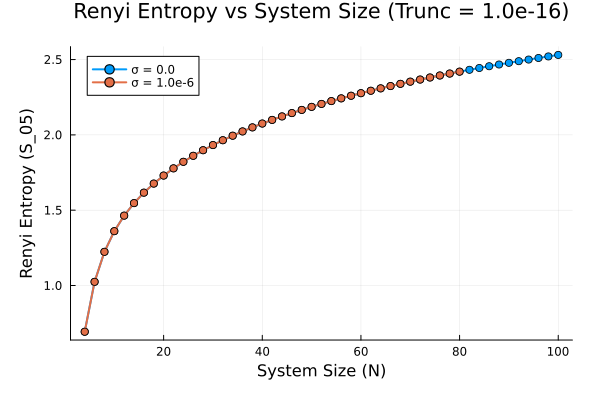

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_Fidelity\\images\\ent_s05.png"

In [41]:
target_sigmas = [0.0, 1e-6] 
target_trunc = 1e-16

p_s05 = plot(
    title = "Renyi Entropy vs System Size (Trunc = $target_trunc)",
    xlabel = "System Size (N)",
    ylabel = "Renyi Entropy (S_05)",
    legend = :topleft,    
    # xscale = :log10,
    margin = 5Plots.mm,
    grid = true
)

for σ in target_sigmas
    if haskey(all_data, target_trunc) && haskey(all_data[target_trunc], σ)
        data = all_data[target_trunc][σ]
        
        N_range = data["N_range"]
        s05_entropy = data["s05_avg"]

        mask = s05_entropy .> 0.0
        
        valid_N = N_range[mask]
        valid_ent = s05_entropy[mask]
        
        if !isempty(valid_ent)
            plot!(p_s05, valid_N, valid_ent, 
                label = "σ = $(σ)", 
                marker = :circle, 
                linewidth = 2)

        end
    else
        println("Warning: Data not found for Trunc = $target_trunc, σ = $σ")
    end
end

display(p_s05)
savefig(p_s05, joinpath("images", "ent_s05.png"))

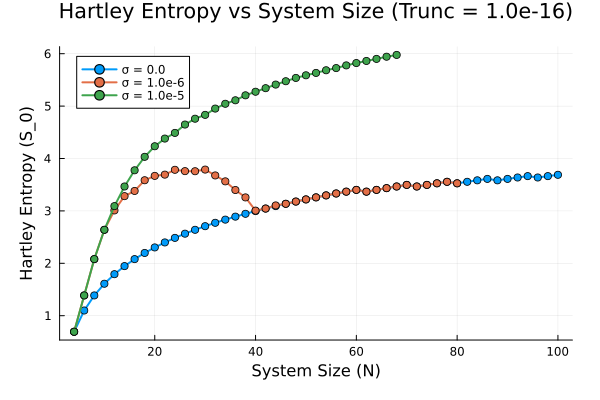

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_Fidelity\\images\\ent_s0.png"

In [42]:
target_sigmas = [0.0, 1e-6, 1e-5] 
target_trunc = 1e-16

p_s0 = plot(
    title = "Hartley Entropy vs System Size (Trunc = $target_trunc)",
    xlabel = "System Size (N)",
    ylabel = "Hartley Entropy (S_0)",
    legend = :topleft,    
    # xscale = :log10,
    margin = 5Plots.mm,
    grid = true
)

for σ in target_sigmas
    if haskey(all_data, target_trunc) && haskey(all_data[target_trunc], σ)
        data = all_data[target_trunc][σ]
        
        N_range = data["N_range"]
        s0_entropy = data["s0_avg"]

        mask = s0_entropy .> 0.0
        
        valid_N = N_range[mask]
        valid_ent = s0_entropy[mask]

        if σ == 1e-6
            palette_idx = 2  
        elseif σ == 1e-5
            palette_idx = 3 
        else
            palette_idx = 1  
        end
        
        if !isempty(valid_ent)
            plot!(p_s0, valid_N, valid_ent, 
                label = "σ = $(σ)", 
                marker = :circle, 
                color = palette_idx,
                linewidth = 2)

        end
    else
        println("Warning: Data not found for Trunc = $target_trunc, σ = $σ")
    end
end

display(p_s0)
savefig(p_s0, joinpath("images", "ent_s0.png"))

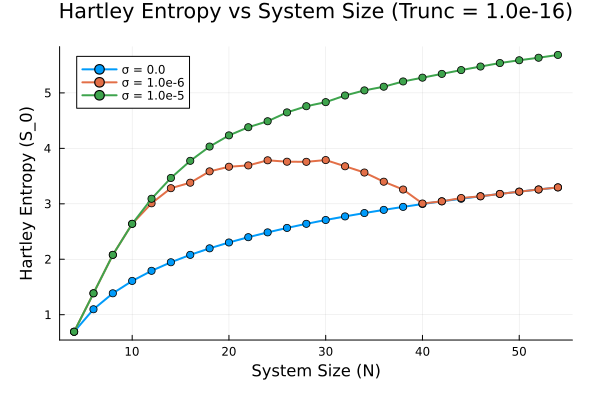

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_Fidelity\\images\\ent_s0_zoom.png"

In [43]:
target_sigmas = [0.0, 1e-6, 1e-5] 
target_trunc = 1e-16
target_N_range = 2:54 

p_s0 = plot(
    title = "Hartley Entropy vs System Size (Trunc = $target_trunc)",
    xlabel = "System Size (N)",
    ylabel = "Hartley Entropy (S_0)",
    legend = :topleft,    
    # xscale = :log10,
    margin = 5Plots.mm,
    grid = true
)

for σ in target_sigmas
    if haskey(all_data, target_trunc) && haskey(all_data[target_trunc], σ)
        data = all_data[target_trunc][σ]
        
        data_N = data["N_range"]
        s0_entropy = data["s0_avg"]

        mask = (s0_entropy .> 0.0) .& in.(data_N, Ref(target_N_range))
        
        valid_N = data_N[mask]
        valid_ent = s0_entropy[mask]

        if σ == 1e-6
            palette_idx = 2  
        elseif σ == 1e-5
            palette_idx = 3 
        else
            palette_idx = 1  
        end
        
        if !isempty(valid_ent)
            plot!(p_s0, valid_N, valid_ent, 
                label = "σ = $(σ)", 
                marker = :circle, 
                color = palette_idx,
                linewidth = 2)

        end
    else
        println("Warning: Data not found for Trunc = $target_trunc, σ = $σ")
    end
end

display(p_s0)
savefig(p_s0, joinpath("images", "ent_s0_zoom.png"))

# Finding the sigmas which deviate from the logarithmic case

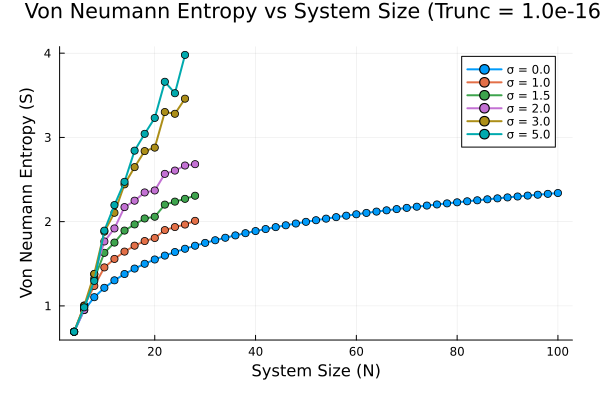

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_Fidelity\\images\\ent_vn_large.png"

In [44]:
# target_sigmas = sigma_values
target_sigmas = [0.0, 1, 1.5, 2, 3, 5]
target_trunc = 1e-16

p_vn = plot(
    title = "Von Neumann Entropy vs System Size (Trunc = $target_trunc)",
    xlabel = "System Size (N)",
    ylabel = "Von Neumann Entropy (S)",
    legend = :topright,    
    # xscale = :log10,
    margin = 5Plots.mm,
    grid = true
)

for σ in target_sigmas
    if haskey(all_data, target_trunc) && haskey(all_data[target_trunc], σ)
        data = all_data[target_trunc][σ]
        
        N_range = data["N_range"]
        vn_entropy = data["vn_avg"]

        mask = vn_entropy .> 0.0
        
        valid_N = N_range[mask]
        valid_vn = vn_entropy[mask]
        
        if !isempty(valid_vn)
            plot!(p_vn, valid_N, valid_vn, 
                label = "σ = $(σ)", 
                marker = :circle, 
                linewidth = 2)

        end
    else
        println("Warning: Data not found for Trunc = $target_trunc, σ = $σ")
    end
end

display(p_vn)
savefig(p_vn, joinpath("images", "ent_vn_large.png"))

# Fidelity


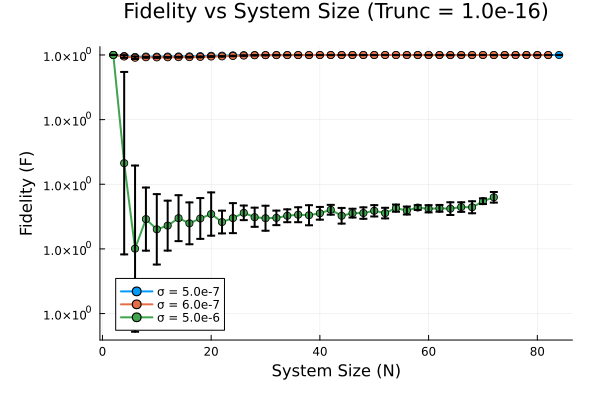

GKS: Possible loss of precision in routine SET_WINDOW


"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_Fidelity\\images\\fid.png"

In [45]:
target_sigmas = [5e-7, 6e-7, 5e-6] 
target_trunc = 1e-16

p_fid = plot(
    title = "Fidelity vs System Size (Trunc = $target_trunc)",
    xlabel = "System Size (N)",
    ylabel = "Fidelity (F)",
    legend = :bottomleft,  
    margin = 5Plots.mm,
    grid = true
)

for σ in target_sigmas
    if haskey(all_data, target_trunc) && haskey(all_data[target_trunc], σ)
        data = all_data[target_trunc][σ]
        
        N_full = data["N_range"]
        mask = data["avg_arr"] .> 0 
        
        N_vals = N_full[mask]
        fid_avg = data["fid_avg"][mask]
        fid_err_full = data["fid_err"]
        
        if σ == 0.0
            err_bars = nothing
        else
            err_bars = fid_err_full[mask]
        end

        plot!(p_fid, N_vals, fid_avg, 
            yerror = err_bars,
            label = "σ = $(σ)", 
            marker = :circle, 
            linewidth = 2)
    else
        println("Warning: Data not found for Trunc = $target_trunc, σ = $σ")
    end
end

display(p_fid)
savefig(p_fid, joinpath("images", "fid.png"))

# Infidelity


In [46]:
"""
    get_infidelity_data(all_data, target_trunc, target_sigma)

Extracts system size (N), infidelity (beta), and error bars for a specific 
truncation and sigma from the loaded data dictionary.
"""
function get_infidelity_data(all_data, target_trunc, target_sigma)
    if haskey(all_data, target_trunc) && haskey(all_data[target_trunc], target_sigma)
        data = all_data[target_trunc][target_sigma]
        

        N_full = data["N_range"]
        mask = data["avg_arr"] .> 0 
        
        N_vals = N_full[mask]
        xi_vals = data["fid_avg"][mask] 
        xi_errs = data["fid_err"][mask] 
        

        beta_vals = sqrt.(max.(0.0, 1.0 .- xi_vals.^2))
        

        beta_errs = Float64[]
        for (x, b, dx) in zip(xi_vals, beta_vals, xi_errs)
            if b > 1e-10
                push!(beta_errs, (x / b) * dx)
            else
                push!(beta_errs, 0.0) 
            end
        end
        
        return N_vals, beta_vals, beta_errs
    else
        @warn "Data not found for Trunc = $target_trunc, σ = $target_sigma"
        return nothing
    end
end

get_infidelity_data

# Infidelity with changing Sigma

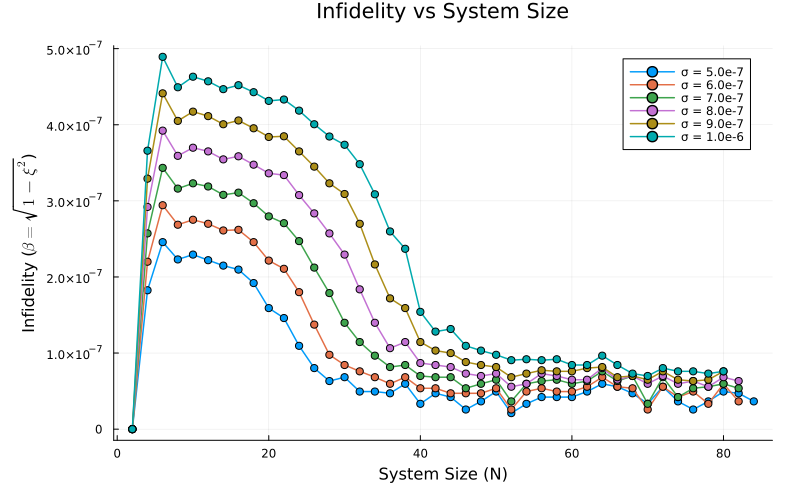

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_Fidelity\\images\\infid_vs_sys.png"

In [47]:


target_trunc = 1e-16
chosen_sigmas = sigma_values_with_spike
chosen_sigmas = [5e-7, 6e-7, 7e-7, 8e-7, 9e-7, 1e-6]

p_infid = plot(
    title = "Infidelity vs System Size",
    xlabel = "System Size (N)",
    ylabel = L"Infidelity ($\beta = \sqrt{1 - \xi^2}$)",
    legend = :topright,
    grid = true,
    size = (800, 500),
    margin = 5Plots.mm
)

for σ in chosen_sigmas
    result = get_infidelity_data(all_data, target_trunc, σ)
    if !isnothing(result)
        N_vals, beta_vals, beta_errs = result
        plot!(p_infid, N_vals, beta_vals, 
            # yerror = beta_errs,
            label = "σ = $σ", 
            marker = :circle, 
            markersize = 4,
            linewidth = 1.5)
    end
end

display(p_infid)
savefig(p_infid, joinpath("images", "infid_vs_sys.png"))

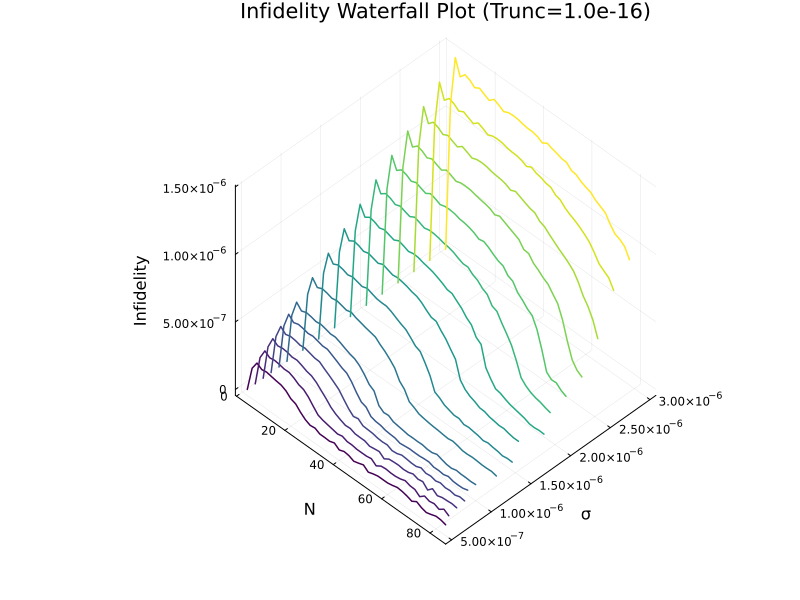

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_Fidelity\\images\\infid_waterfall.png"

In [48]:
target_trunc = 1e-16
chosen_sigmas = sigma_values_with_spike

if haskey(all_data, target_trunc)
    valid_sigmas = filter(σ -> haskey(all_data[target_trunc], σ), chosen_sigmas)
    available_sigmas = sort(valid_sigmas)
    
    if isempty(available_sigmas)
        println("None of the chosen sigmas were found for Truncation $target_trunc.")
    else
        p_waterfall_infid = plot(
            xlabel = "N",
            ylabel = "σ",
            zlabel = "Infidelity",
            title = "Infidelity Waterfall Plot (Trunc=$(target_trunc))",
            camera = (45, 45),
            legend = false,
            size = (800, 600)
        )
        
        line_colors = palette(:viridis, length(available_sigmas))
        
        plot_count = 0
        
        for (idx, σ) in enumerate(available_sigmas)
            result = get_infidelity_data(all_data, target_trunc, σ)
            
            if !isnothing(result)
                N_vals, beta_vals, beta_errs = result
                
                if !isempty(N_vals)
                    Y_vals = fill(σ, length(N_vals))
                    
                    plot!(p_waterfall_infid, N_vals, Y_vals, beta_vals,
                          linecolor = line_colors[idx], linewidth = 1.5)
                    
                    plot_count += 1
                end
            end
        end
        
        if plot_count > 0
            display(p_waterfall_infid)
        else
            println("No valid infidelity data found to plot for the chosen sigmas.")
        end
    end
else
    println("Data for Truncation $target_trunc not found.")
end

savefig(p_waterfall_infid, joinpath("images", "infid_waterfall.png"))

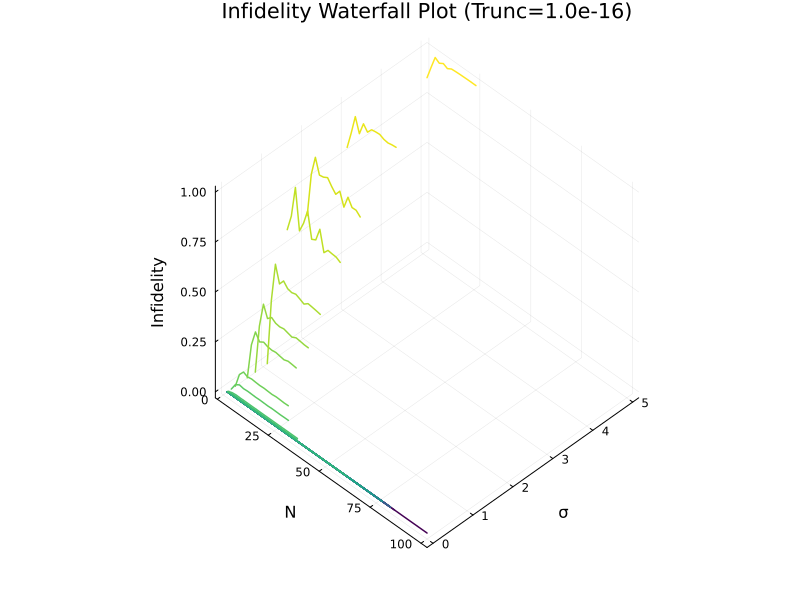

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_Fidelity\\images\\infid_waterfall_all.png"

In [49]:

target_trunc = 1e-16

if haskey(all_data, target_trunc)
    available_sigmas = sort(collect(keys(all_data[target_trunc])))
    
    p_waterfall_infid = plot(
        xlabel = "N",
        ylabel = "σ",
        zlabel = "Infidelity",
        title = "Infidelity Waterfall Plot (Trunc=$(target_trunc))",
        camera = (45, 45),
        legend = false,
        size = (800, 600)
    )
    
    line_colors = palette(:viridis, length(available_sigmas))
    
    plot_count = 0
    
    for (idx, σ) in enumerate(available_sigmas)
        result = get_infidelity_data(all_data, target_trunc, σ)
        
        if !isnothing(result)
            N_vals, beta_vals, beta_errs = result
            
            if !isempty(N_vals)
                Y_vals = fill(σ, length(N_vals))
                
                plot!(p_waterfall_infid, N_vals, Y_vals, beta_vals,
                      linecolor = line_colors[idx], linewidth = 1.5)
                
                plot_count += 1
            end
        end
    end
    
    if plot_count > 0
        display(p_waterfall_infid)
    else
        println("No valid infidelity data found to plot for Truncation $target_trunc.")
    end
else
    println("Data for Truncation $target_trunc not found.")
end

savefig(p_waterfall_infid, joinpath("images", "infid_waterfall_all.png"))

# Infidelity with changing truncation


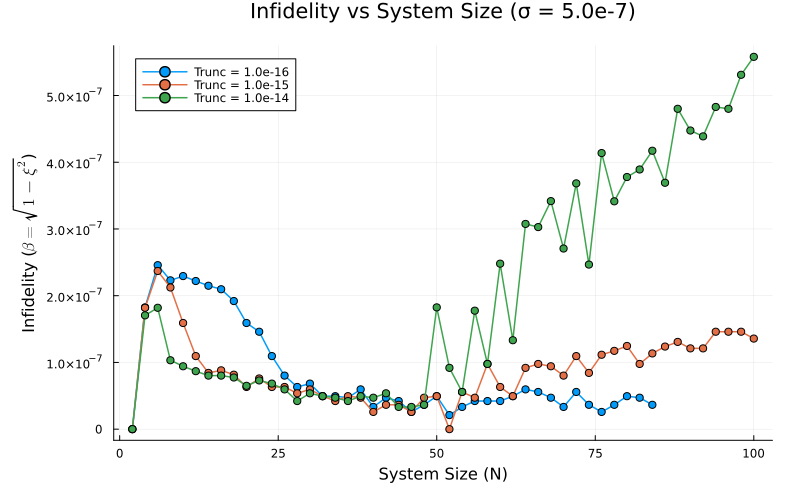

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_Fidelity\\images\\infid_vs_sys_trunc.png"

In [50]:
target_sigma = 5e-7
# chosen_truncs = trunc_values
chosen_truncs = [1e-16, 1e-15, 1e-14]

p_infid = plot(
    title = "Infidelity vs System Size (σ = $target_sigma)",
    xlabel = "System Size (N)",
    ylabel = L"Infidelity ($\beta = \sqrt{1 - \xi^2}$)",
    legend = :topleft,
    grid = true,
    size = (800, 500),
    margin = 5Plots.mm
)

for trunc in chosen_truncs
    result = get_infidelity_data(all_data, trunc, target_sigma)
    
    if !isnothing(result)
        N_vals, beta_vals, beta_errs = result
        plot!(p_infid, N_vals, beta_vals, 
            # yerror = beta_errs,
            label = "Trunc = $trunc",
            marker = :circle, 
            markersize = 4,
            linewidth = 1.5)
    end
end

display(p_infid)
savefig(p_infid, joinpath("images", "infid_vs_sys_trunc.png"))

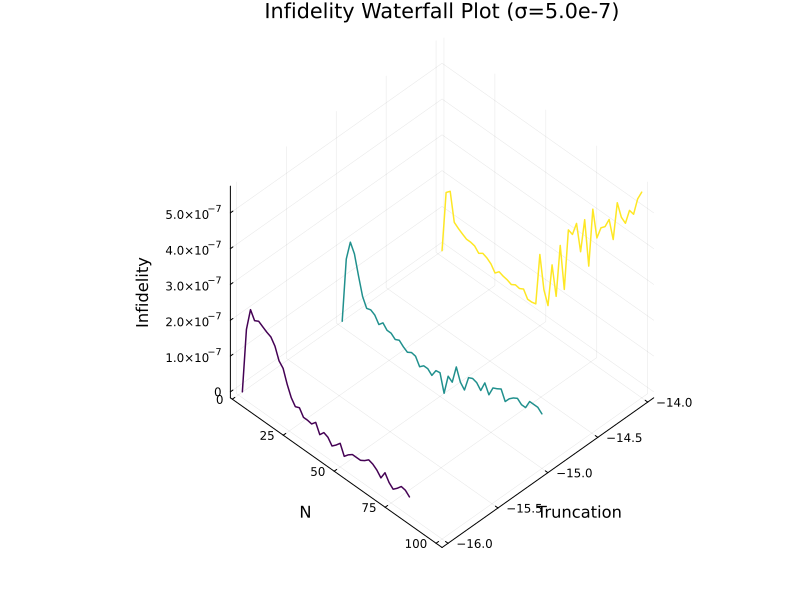

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_Fidelity\\images\\infid_waterfall_trunc.png"

In [51]:

target_sigma = 5e-7 
# chosen_truncs = trunc_values 
chosen_truncs = [1e-16, 1e-15, 1e-14]

valid_truncs = filter(t -> haskey(all_data, t) && haskey(all_data[t], target_sigma), chosen_truncs)
available_truncs = sort(valid_truncs)

if isempty(available_truncs)
    println("None of the chosen truncations were found for Sigma $target_sigma.")
else
    p_waterfall_infid = plot(
        xlabel = "N",
        ylabel = "Truncation", 
        zlabel = "Infidelity",
        title = "Infidelity Waterfall Plot (σ=$(target_sigma))",
        camera = (45, 45),
        legend = false,
        size = (800, 600)
    )
    
    line_colors = palette(:viridis, length(available_truncs))
    
    plot_count = 0
    
    for (idx, t) in enumerate(available_truncs)
        result = get_infidelity_data(all_data, t, target_sigma)
        
        if !isnothing(result)
            N_vals, beta_vals, beta_errs = result
            
            if !isempty(N_vals)
                Y_vals = fill(t, length(N_vals)) 
                
                Y_vals = fill(log10(t), length(N_vals))
                
                plot!(p_waterfall_infid, N_vals, Y_vals, beta_vals,
                      linecolor = line_colors[idx], linewidth = 1.5)
                
                plot_count += 1
            end
        end
    end
    

    display(p_waterfall_infid)

end
savefig(p_waterfall_infid, joinpath("images", "infid_waterfall_trunc.png"))

# Fidelity vs Disorder

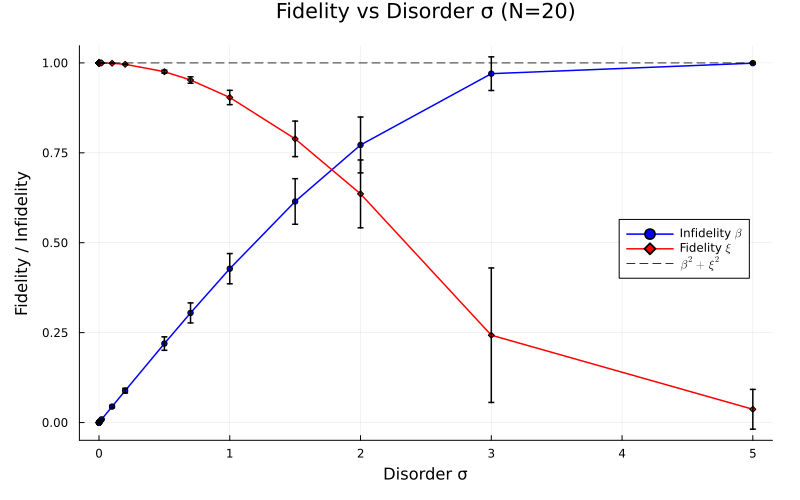

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_Fidelity\\images\\fid_inf_vs_sigma_N=20.png"

In [52]:

target_N = 20
target_trunc = 1e-16

βs = Float64[]
ξs = Float64[]
β_errs = Float64[]
ξ_errs = Float64[]
valid_σs = Float64[]

if haskey(all_data, target_trunc)
    available_sigmas = sort(collect(keys(all_data[target_trunc])))
    
    for σ in available_sigmas
        data = all_data[target_trunc][σ]
        
        if haskey(data, "N_range")
            N_range = data["N_range"]
            idx = findfirst(x -> x == target_N, N_range)
            
            if !isnothing(idx)

                xi_val = data["fid_avg"][idx]
                xi_err = haskey(data, "fid_err") ? data["fid_err"][idx] : 0.0
                

                result = get_infidelity_data(all_data, target_trunc, σ)
                
                if !isnothing(result)
                    N_vals, beta_vals, beta_errors = result
                    b_idx = findfirst(x -> x == target_N, N_vals)
                    
                    if !isnothing(b_idx)
                        push!(valid_σs, σ)
                        push!(ξs, xi_val)
                        push!(ξ_errs, xi_err)
                        push!(βs, beta_vals[b_idx])
                        push!(β_errs, beta_errors[b_idx])
                    end
                end
            end
        end
    end
    
    if !isempty(valid_σs)
        p1 = plot(
            title = "Fidelity vs Disorder σ (N=$target_N)",
            xlabel = "Disorder σ", 
            ylabel = "Fidelity / Infidelity",
            legend = :right, 
            grid = true,
            size = (800, 500),
            margin = 5Plots.mm
        )
             
        # Plot Infidelity (β)
        plot!(p1, valid_σs, βs, yerr=β_errs, 
              label=L"Infidelity $\beta$", color=:blue, marker=:circle, markersize=3, linewidth=1.5)
        
        # Plot Fidelity (ξ)
        plot!(p1, valid_σs, ξs, yerr=ξ_errs, 
              label=L"Fidelity $\xi$", color=:red, marker=:diamond, markersize=3, linewidth=1.5)
              
        # Verify β^2 + ξ^2 = 1
        sq_sum = [β^2 + ξ^2 for (β, ξ) in zip(βs, ξs)]
        plot!(p1, valid_σs, sq_sum, label=L"\beta^2+\xi^2", color=:black, alpha=0.8, linestyle=:dash)

        display(p1)
    else
        println("No valid data found for N = $target_N at Truncation $target_trunc.")
    end
else
    println("Data for Truncation $target_trunc not found.")
end

savefig(p1, joinpath("images", "fid_inf_vs_sigma_N=$target_N.png"))

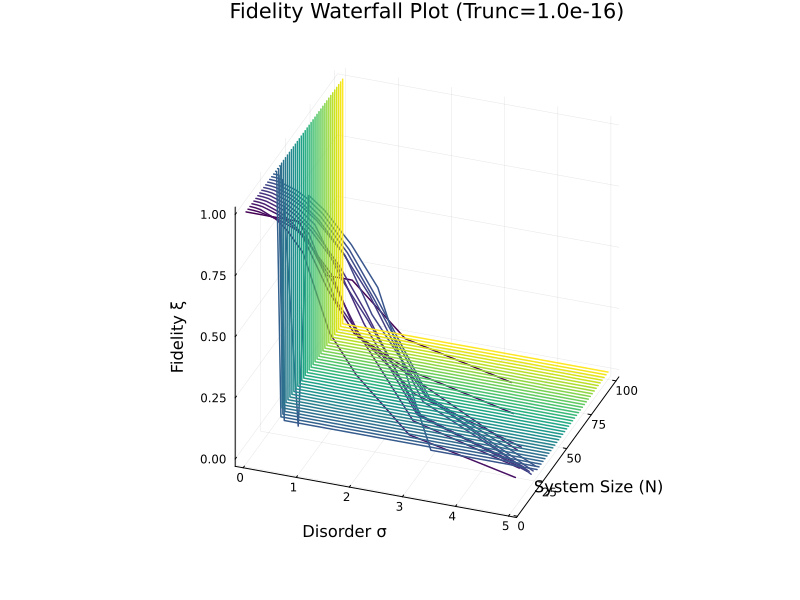

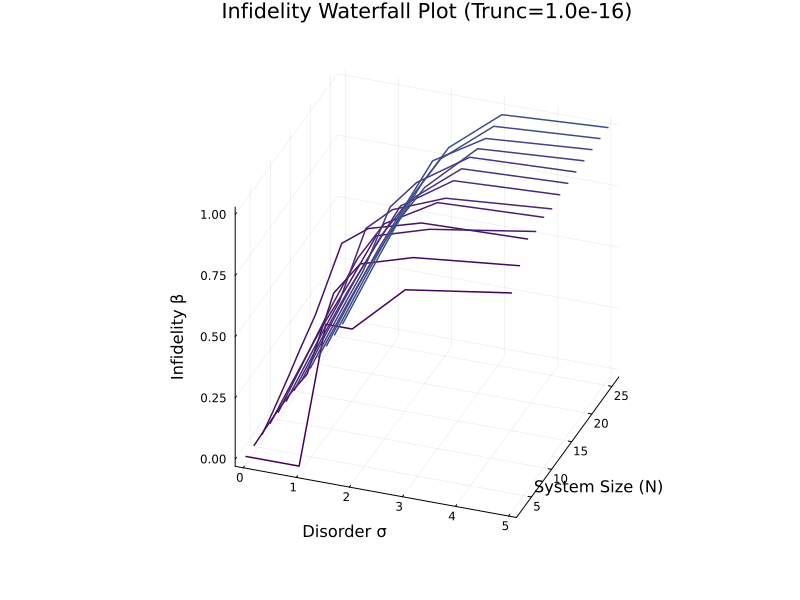

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_Fidelity\\images\\infid_waterfall_full.png"

In [53]:

target_trunc = 1e-16

if haskey(all_data, target_trunc)
    sigmas = sort(collect(keys(all_data[target_trunc])))
    
    unique_Ns = Set{Int}()
    for σ in sigmas
        if haskey(all_data[target_trunc][σ], "N_range")
            union!(unique_Ns, all_data[target_trunc][σ]["N_range"])
        end
    end
    N_vals = sort(collect(unique_Ns))
    
    p_waterfall_fid = plot(
        xlabel = "Disorder σ",
        ylabel = "System Size (N)",
        zlabel = "Fidelity ξ",
        title = "Fidelity Waterfall Plot (Trunc=$(target_trunc))",
        camera = (20, 30),
        legend = false,
        size = (800, 600)
    )
    
    p_waterfall_infid = plot(
        xlabel = "Disorder σ",
        ylabel = "System Size (N)",
        zlabel = "Infidelity β",
        title = "Infidelity Waterfall Plot (Trunc=$(target_trunc))",
        camera = (20, 30),
        legend = false,
        size = (800, 600)
    )
    
    line_colors = palette(:viridis, length(N_vals))
    
    fid_plot_count = 0
    infid_plot_count = 0
    
    for (idx, N) in enumerate(N_vals)
        loc_sigmas = Float64[]
        loc_fids = Float64[]
        loc_infids = Float64[]
        
        for σ in sigmas
            data = all_data[target_trunc][σ]
            
            if haskey(data, "N_range") && haskey(data, "fid_avg")
                n_idx = findfirst(x -> x == N, data["N_range"])
                
                if !isnothing(n_idx)
                    push!(loc_sigmas, σ)
                    push!(loc_fids, data["fid_avg"][n_idx])
                    
                    result = get_infidelity_data(all_data, target_trunc, σ)
                    if !isnothing(result)
                        N_vals_infid, beta_vals, _ = result
                        b_idx = findfirst(x -> x == N, N_vals_infid)
                        
                        if !isnothing(b_idx)
                            push!(loc_infids, beta_vals[b_idx])
                        end
                    end
                end
            end
        end
        
        if !isempty(loc_fids) && length(loc_sigmas) == length(loc_fids)
            Y_vals = fill(N, length(loc_sigmas))
            plot!(p_waterfall_fid, loc_sigmas, Y_vals, loc_fids,
                  linecolor = line_colors[idx], linewidth = 1.5)
            fid_plot_count += 1
        end
        
        if !isempty(loc_infids) && length(loc_sigmas) == length(loc_infids)
            Y_vals = fill(N, length(loc_sigmas))
            plot!(p_waterfall_infid, loc_sigmas, Y_vals, loc_infids,
                  linecolor = line_colors[idx], linewidth = 1.5)
            infid_plot_count += 1
        end
    end
    
    if fid_plot_count > 0
        display(p_waterfall_fid)
    else
        println("No valid fidelity data found to plot.")
    end
    
    if infid_plot_count > 0
        display(p_waterfall_infid)
    else
        println("No valid infidelity data found to plot.")
    end

else
    println("Data for Truncation $target_trunc not found.")
end

savefig(p_waterfall_fid, joinpath("images", "fid_waterfall_full.png"))
savefig(p_waterfall_infid, joinpath("images", "infid_waterfall_full.png"))